# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
from sklearn import preprocessing
import statsmodels.api as sm
import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

# Setting the directory for data

In [93]:
dir("/Users/ljunodrstat/CStat2026_project/")
os.listdir()

['CP_project_midterm_presentation.pptx',
 '.DS_Store',
 'report.md',
 'project_STUDENTID_processed.ipynb.zip',
 'README.md',
 'project_STUDENTID.ipynb',
 '.ipynb_checkpoints',
 '.jupyter',
 '.git',
 'Data',
 'project_STUDENTID_processed.ipynb']

---
## Load Data

In [94]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Cleaning the data
NA Values : Is there any NAs values in the variables of intersts for the project ? If any, how to replace them
Missing values ? 

In [95]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
features_dt = pd.DataFrame(train[features])
features_dt.head()

,OverallQual,ExterQual,BsmtQual,KitchenQual,FireplaceQu,CentralAir,LotShape,LandSlope,MoSold,YrSold
0,7,Gd,Gd,Gd,NaN,Y,Reg,Gtl,2,2008
1,6,TA,Gd,TA,TA,Y,Reg,Gtl,5,2007
2,7,Gd,Gd,Gd,TA,Y,IR1,Gtl,9,2008
3,7,TA,TA,Gd,Gd,Y,IR1,Gtl,2,2006
4,8,Gd,Gd,Gd,TA,Y,IR1,Gtl,12,2008


In [96]:
na_dt = features_dt[features_dt.isna().any(axis=1)]
na_dt.shape

(699, 10)

In [97]:
for col in na_dt.columns:
    na_dt[col].unique()
    print(f"levels of variables {col} : {na_dt[col].unique()}")

levels of variables OverallQual : [7 5 4 8 6 3 9 1 2]
levels of variables ExterQual : ['Gd' 'TA' 'Fa' 'Ex']
levels of variables BsmtQual : ['Gd' 'TA' nan 'Ex' 'Fa']
levels of variables KitchenQual : ['Gd' 'TA' 'Fa' 'Ex']
levels of variables FireplaceQu : [nan 'Gd' 'Ex' 'Po' 'TA']
levels of variables CentralAir : ['Y' 'N']
levels of variables LotShape : ['Reg' 'IR1' 'IR2' 'IR3']
levels of variables LandSlope : ['Gtl' 'Mod' 'Sev']
levels of variables MoSold : [ 2 10  9  7  6  5  1 12  8  3  4 11]
levels of variables YrSold : [2008 2009 2007 2006 2010]


# Nan Values 
We observe nan values in two variables : BsmtQual and FireplaceQu, which means "none" according to the description file of the Data. 
## Solution
We replace them with None for clarity purpose.
# Ordinal Values
6 variables (ExterQual, BsmtQual, KitchenQual, FireplaceQu, LotShape, LandSlope) are ordinal values, ranking a quality in differents rank (4 ranks in general, 3 for the LandSlope)
## Solution
Outside of OverallQual, which is numeric of type string, we need to correct them by adding a rank, by using a dictionnary. 

# NAN values

In [98]:
features_dt['BsmtQual'] = features_dt['BsmtQual'].replace('nan', 'No_Basement')

features_dt['FireplaceQu'] = features_dt['FireplaceQu'].replace('nan', 'No_Fireplace')
features_dt
features_dt['FireplaceQu'].unique()
features_dt['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

## Dictionnaries

In [99]:
qual_dict = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0,
    'No_basement': 0,
    'No_Fireplace': 0,
    'No_Kitchen': 0
}
slope_dict = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1,   
    'NA': 0}
lotshape_dict = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1,
    'NA': 0}

features_dt['ExterQual'] = features_dt['ExterQual'].map(qual_dict)
features_dt['BsmtQual'] = features_dt['BsmtQual'].map(qual_dict)
features_dt['KitchenQual'] = features_dt['KitchenQual'].map(qual_dict)
features_dt['FireplaceQu'] = features_dt['FireplaceQu'].map(qual_dict)

features_dt['LotShape'] = features_dt['LotShape'].map(lotshape_dict)
features_dt['LandSlope'] = features_dt['LandSlope'].map(slope_dict)


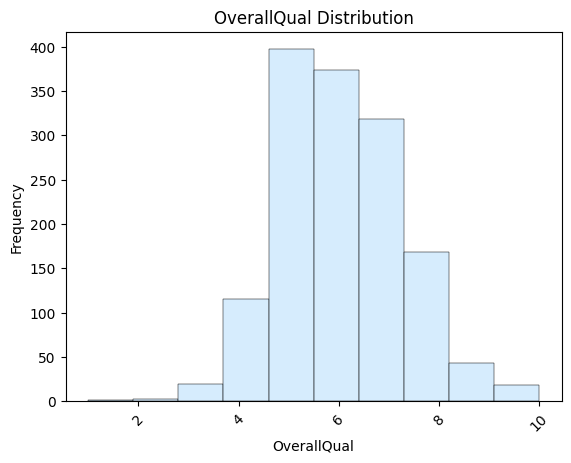

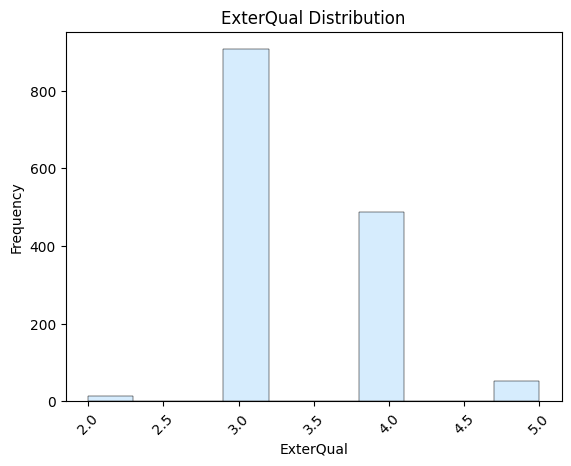

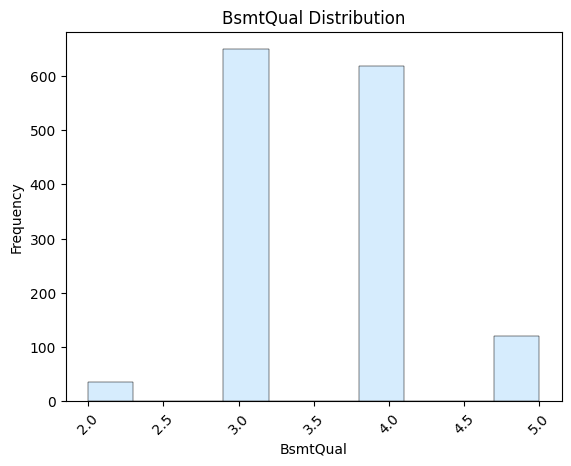

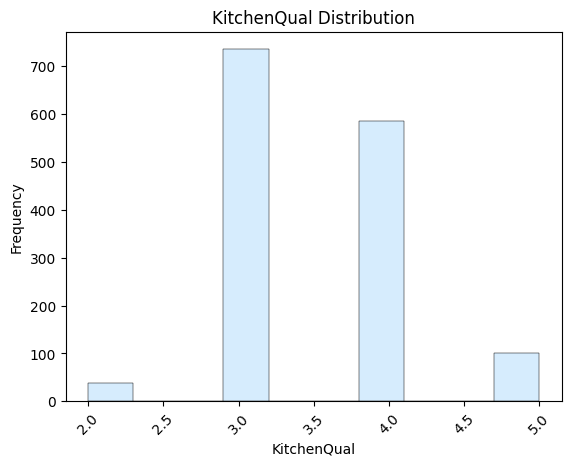

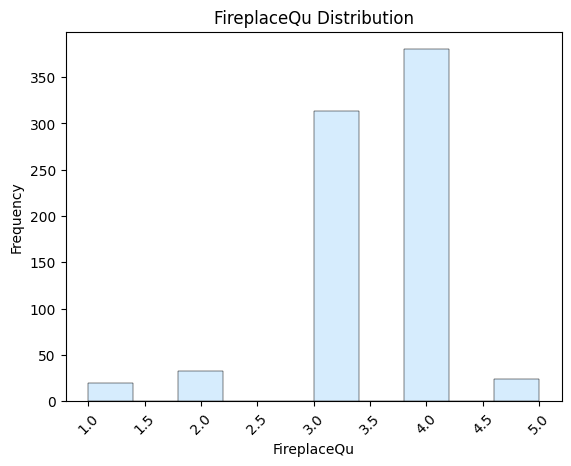

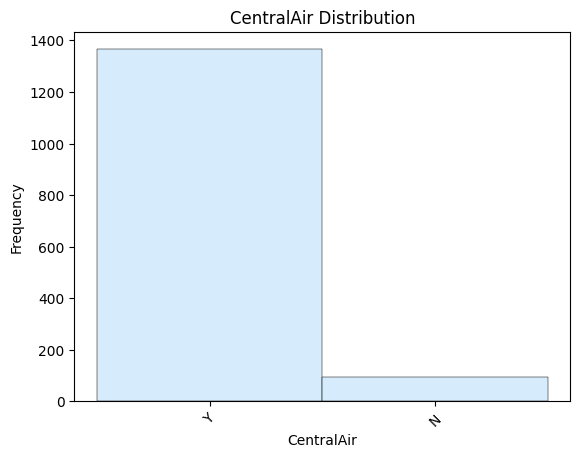

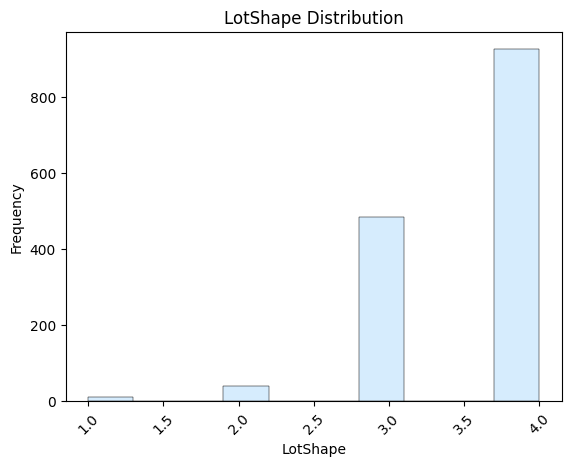

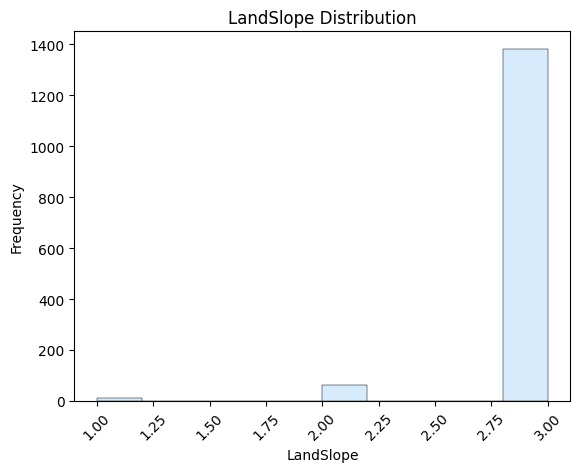

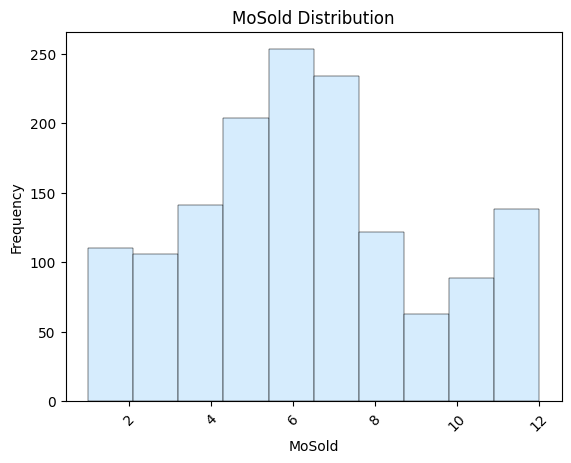

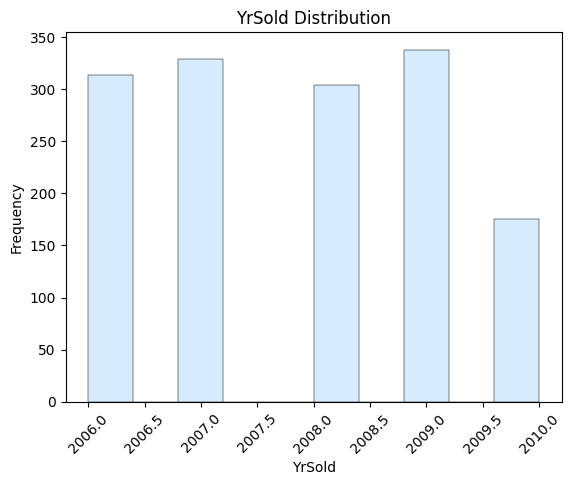

In [100]:

for col in features_dt.columns:
    sns.histplot(features_dt[col], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

The corrections give favorable results, we apply them to the train dataframe

In [101]:
train['ExterQual'] = train['ExterQual'].map(qual_dict)
train['BsmtQual'] = train['BsmtQual'].map(qual_dict)
train['KitchenQual'] = train['KitchenQual'].map(qual_dict)
train['FireplaceQu'] = train['FireplaceQu'].map(qual_dict)

train['LotShape'] = train['LotShape'].map(lotshape_dict)
train['LandSlope'] = train['LandSlope'].map(slope_dict)

train['BsmtQual'] = train['BsmtQual'].replace('nan', 'No_Basement')

train['FireplaceQu'] = train['FireplaceQu'].replace('nan', 'No_Fireplace')

<Axes: xlabel='LotShape', ylabel='Count'>

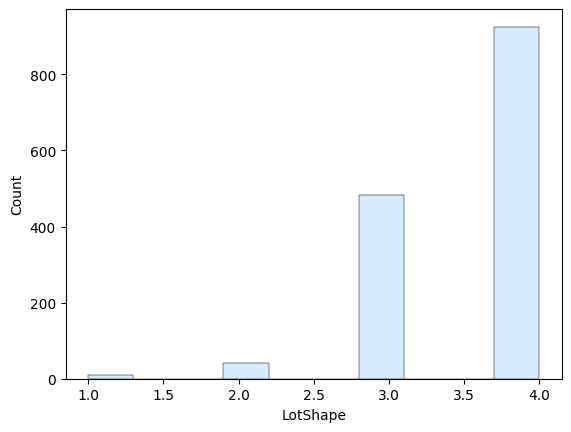

In [102]:
sns.histplot(train['LotShape'], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


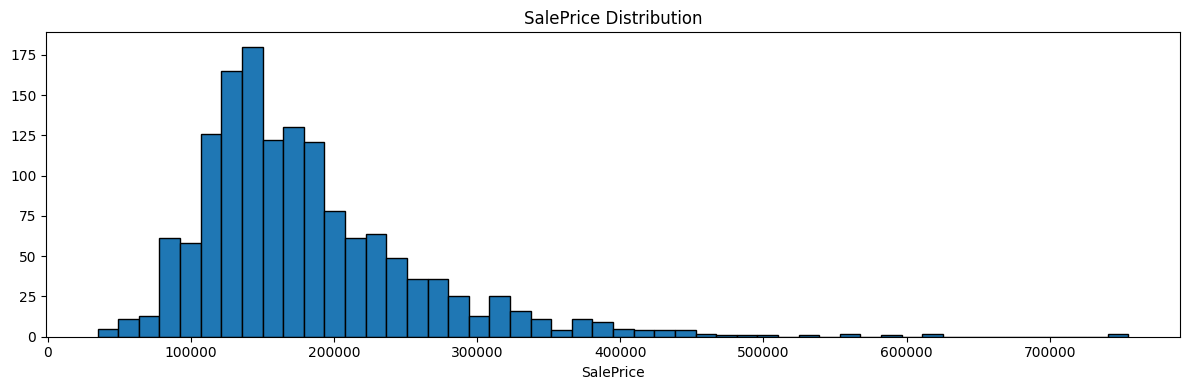

Skewness: 1.883


In [103]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

A log transformation can bring a normal distribution

---
## Part 1: Classical Statistical Inference



Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

Sample Mean and Variance of SalePrice and key features


In [119]:
mean_SalePrice = train['SalePrice'].mean()
median_SalePrice = train['SalePrice'].median()
std_SalePrice = train['SalePrice'].std()
print(f'Mean: {mean_SalePrice:.2f}')
print(f'Median: {median_SalePrice:.2f}')
print(f'Standard Deviation: {std_SalePrice:.2f}')



Mean: 180921.20
Median: 163000.00
Standard Deviation: 79442.50


# Classement des features selon leur type

In [105]:
ordinal_mappings = {
    'ExterQual' : qual_dict,
    'BsmtQual' : qual_dict,
    'KitchenQual' : qual_dict,
    'FireplaceQu' : qual_dict,
    'LotShape' : lotshape_dict,
    'LandSlope' : slope_dict
}


def describe_features(df, feature, ordinal_mappings=None):
    if ordinal_mappings:
        mapped = df[feature].map(ordinal_mappings)
        valid = mapped.dropna()

        print(f"\n{feature} (ordinal ):")
        print(f"  Uniques values : {df[feature].unique()}")
        print(f" Distribution:\n{valid.value_counts().sort_index()}")
        print(f"  Mean: {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    elif pd.api.types.is_numeric_dtype(df[feature]):
        valid = df[feature].dropna()
        print(f"\n{feature} (numerical):")
        print(f" Mean : {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Q1 : {valid.quantile(0.25)}, Q3: {valid.quantile(0.75)}")
        print(f" Missing values: {df[feature].isna().sum()}")
    else: 
        print(f"\n{feature} (categorical):")
        print(f" Unique values: {df[feature].unique()}")
        print(f" Top values :\n {df[feature].nunique()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    
    


In [106]:
features_ordinal = train[['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'LotShape', 'LandSlope']]
features_numerical = train[['SalePrice', 'OverallQual', 'MoSold', 'YrSold']]


In [107]:
print("==== Target : Numerical variables =====")
for feat in features_numerical.columns:
    describe_features(train, feat)



==== Target : Numerical variables =====

SalePrice (numerical):
 Mean : 180921.20, Median: 163000.00, Std Dev: 79442.50
 Min-Max : 34900 - 755000
 Q1 : 129975.0, Q3: 214000.0
 Missing values: 0

OverallQual (numerical):
 Mean : 6.10, Median: 6.00, Std Dev: 1.38
 Min-Max : 1 - 10
 Q1 : 5.0, Q3: 7.0
 Missing values: 0

MoSold (numerical):
 Mean : 6.32, Median: 6.00, Std Dev: 2.70
 Min-Max : 1 - 12
 Q1 : 5.0, Q3: 8.0
 Missing values: 0

YrSold (numerical):
 Mean : 2007.82, Median: 2008.00, Std Dev: 1.33
 Min-Max : 2006 - 2010
 Q1 : 2007.0, Q3: 2009.0
 Missing values: 0


In [108]:
features_ordinal.head()

,ExterQual,BsmtQual,KitchenQual,FireplaceQu,LotShape,LandSlope
0,4,4.0,4,NaN,4,3
1,3,4.0,3,3.0,4,3
2,4,4.0,4,3.0,3,3
3,3,3.0,4,4.0,3,3
4,4,4.0,4,3.0,3,3


In [109]:
print("\n=== Ordinal features ==== ")
for feat in features_ordinal.columns:
        describe_features(train, feat)


=== Ordinal features ==== 

ExterQual (numerical):
 Mean : 3.40, Median: 3.00, Std Dev: 0.57
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

BsmtQual (numerical):
 Mean : 3.58, Median: 4.00, Std Dev: 0.68
 Min-Max : 2.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 37

KitchenQual (numerical):
 Mean : 3.51, Median: 3.00, Std Dev: 0.66
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

FireplaceQu (numerical):
 Mean : 3.46, Median: 4.00, Std Dev: 0.74
 Min-Max : 1.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 690

LotShape (numerical):
 Mean : 3.59, Median: 4.00, Std Dev: 0.58
 Min-Max : 1 - 4
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

LandSlope (numerical):
 Mean : 2.94, Median: 3.00, Std Dev: 0.28
 Min-Max : 1 - 3
 Q1 : 3.0, Q3: 3.0
 Missing values: 0


## Confidence intervals 
### for the mean SalePrice

In [ ]:
mean_SalePrice = train['SalePrice'].mean()
std_SalePrice = train['SalePrice'].std()

CI_saleprice = stats.interval(0.95, len(train)-1, loc=mean_SalePrice, scale=std_SalePrice/np.sqrt(len(train)))

In [126]:
print(f"mean of SalePrice: {mean_SalePrice:.2f}")
print(f"std of SalePrice: {std_SalePrice:.2f}")

mean of SalePrice: 180921.20
std of SalePrice: 79442.50


In [121]:
print(f" 95% Confidence Interval for SalePrice: {CI_saleprice}")

 95% Confidence Interval for SalePrice: (np.float64(176842.84104108496), np.float64(184999.55073973694))


CI_saleprice[0]: 176842.84104108496
CI_saleprice[1]: 184999.55073973694


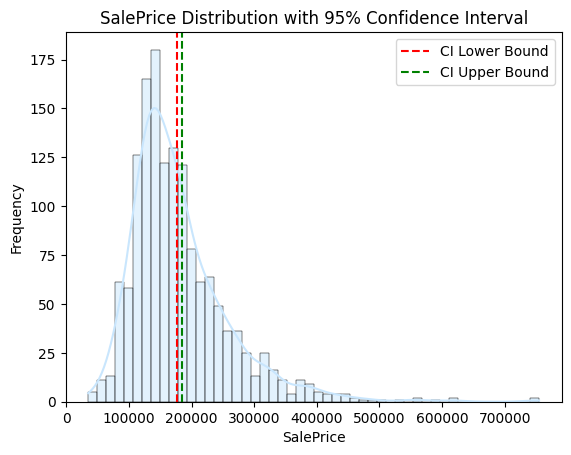

In [124]:
type(CI_saleprice)
print("CI_saleprice[0]:", CI_saleprice[0])
print("CI_saleprice[1]:", CI_saleprice[1])
sns.histplot(train['SalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)
plt.axvline(CI_saleprice[0], color='red', linestyle='--', label='CI Lower Bound')
plt.axvline(CI_saleprice[1], color='green', linestyle='--', label='CI Upper Bound')
plt.title('SalePrice Distribution with 95% Confidence Interval')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Skewness after log transformation: 0.121


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_26820/1451824775.py:14: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_26820/1451824775.py:14: SyntaxWarning: invalid escape sequence '\s'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')


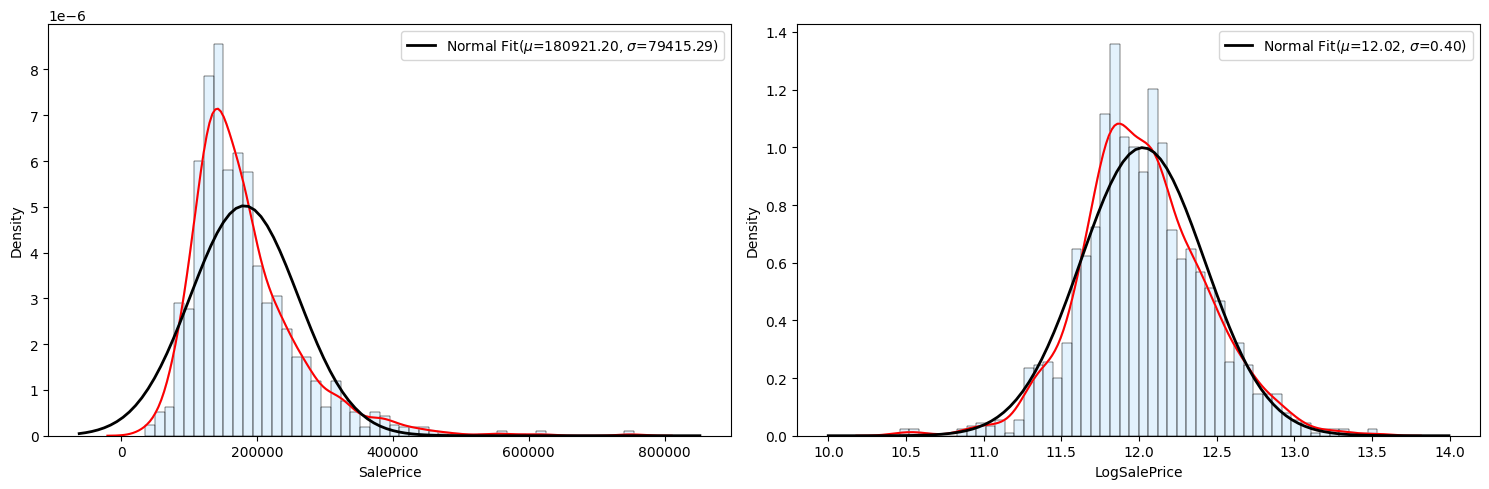

In [111]:
from scipy import stats
train['LogSalePrice'] = np.log(train['SalePrice'])
print(f'Skewness after log transformation: {train["LogSalePrice"].skew():.3f}')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = ['SalePrice', 'LogSalePrice']
for i, col in enumerate(cols):
    sns.histplot(train[col], bins=50, ax=axes[i],
                stat='density', kde=True, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    sns.kdeplot(train[col], ax=axes[i], color='red', linewidth=1.5)
    mu, std = stats.norm.fit(train[col])
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()

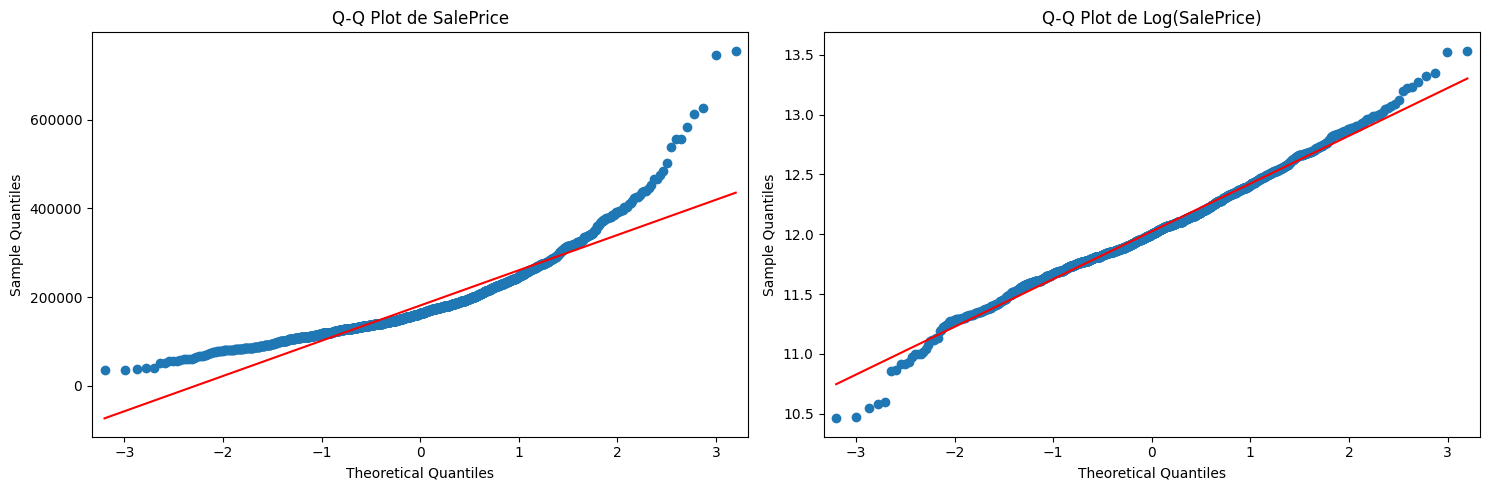

In [112]:
#Q-Q plot for SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sm.qqplot(train['SalePrice'], line='s', ax=axes[0])
sm.qqplot(train['LogSalePrice'], line='s', ax=axes[1])
axes[0].set_title('Q-Q Plot de SalePrice')
axes[1].set_title('Q-Q Plot de Log(SalePrice)')
axes[0].set_title('Q-Q Plot de SalePrice')
axes[1].set_title('Q-Q Plot de Log(SalePrice)')
plt.tight_layout()
plt.show()


In [113]:
#Shapiro-Wilk test for SalePrice
shapiro_test = stats.shapiro(train['LogSalePrice'])
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic: 0.991, p-value: 1.149e-07


Le résultat des QQplots et du test de shapiro (H0 distribution normale) avec W = 0.991 avec une p-value < 0.05 confirme que la transformation de SalePrice en log donne une distribution normale. 

Valeurs nulles

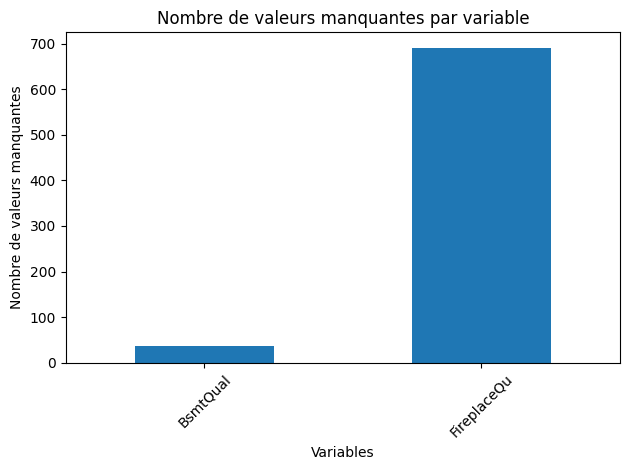

In [114]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_null = train[features]
missing_pd = train_null.isnull()
missing = missing_pd.sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.title('Nombre de valeurs manquantes par variable')
plt.ylabel('Nombre de valeurs manquantes')
plt.xlabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [115]:

#sns.histplot(train_null['OverallQual'], kde=False)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   int64  
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   int64  
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Analyse de TotalBsmtSF

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


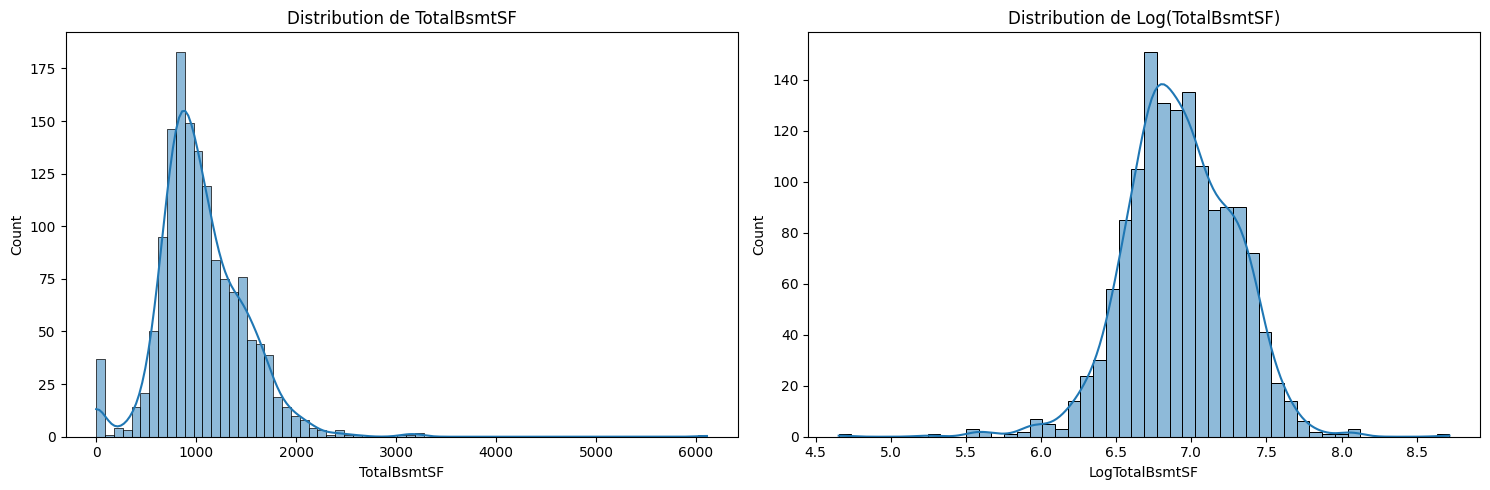

In [116]:
from scipy import stats
train['TotalBsmtSF']
train['LogTotalBsmtSF'] = np.log(train['TotalBsmtSF'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de TotalBsmtSF')
sns.histplot(train['TotalBsmtSF'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(TotalBsmtSF)')
sns.histplot(train['LogTotalBsmtSF'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

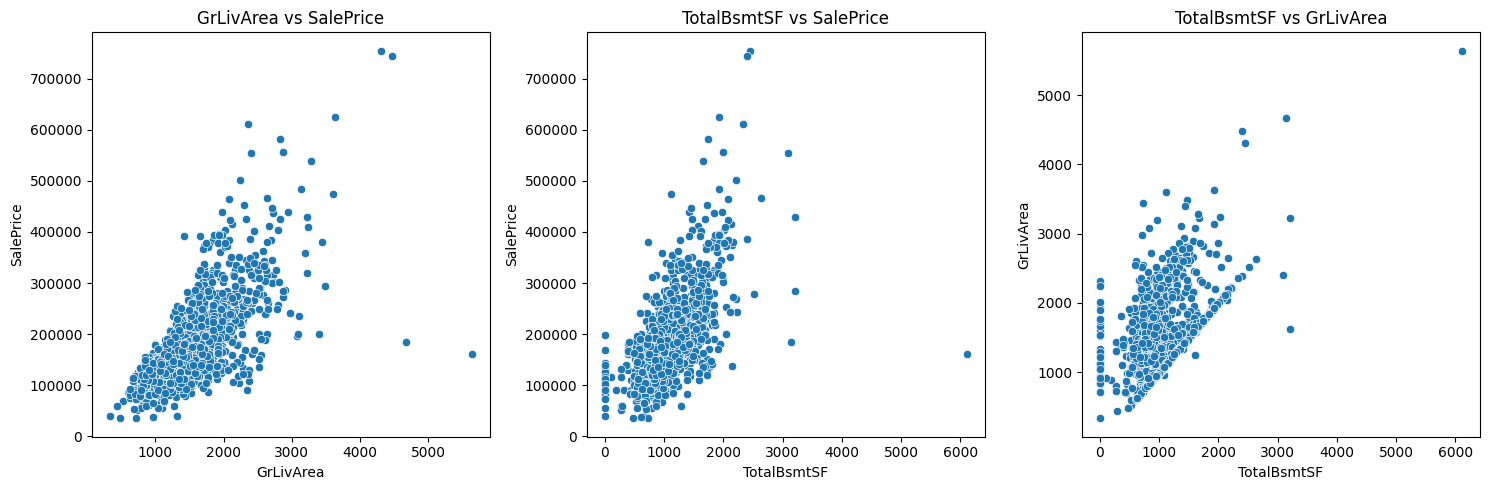

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='GrLivArea', data=train, ax=axes[2])
axes[2].set_title('TotalBsmtSF vs GrLivArea')
plt.tight_layout()

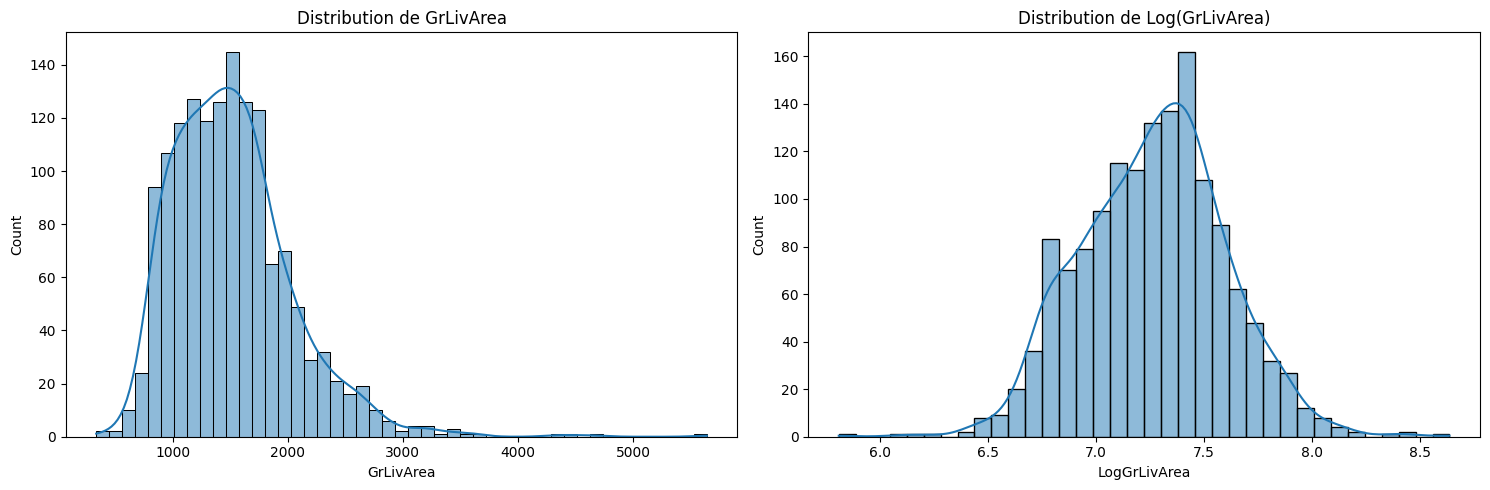

In [118]:
from scipy import stats

train['LogGrLivArea'] = np.log(train['GrLivArea'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de GrLivArea')
sns.histplot(train['GrLivArea'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(GrLivArea)')
sns.histplot(train['LogGrLivArea'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

ANOVA a un facteur

In [ ]:
Lotshape_pd = pd.Datafram[]
sns.barplot(data=train, x='SalePrice', y="LotShape", hue="index")

plt.show()

ValueError: Could not interpret value `index` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_anova = train[features + ['LogSalePrice']].copy()
for col in features:
    train_anova[col] = train_anova[col].fillna('None').astype('category')
anova_results = []
for col in features:
    model = ols(f'LogSalePrice ~ C({col})', data=train_anova).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    anova_results.append({'Feature': col, 'p-value': p_value, 'Significant': p_value < 0.05})
df_anova = pd.DataFrame(anova_results)
print(df_anova.sort_values(by='p-value'))


       Feature        p-value  Significant
0  OverallQual   0.000000e+00         True
1    ExterQual  6.935425e-195         True
2     BsmtQual  2.031282e-188         True
3  KitchenQual  4.441486e-187         True
4  FireplaceQu  6.963458e-115         True
5   CentralAir   9.855628e-44         True
6     LotShape   7.856968e-29         True
7    LandSlope   3.388375e-01        False
8       MoSold   4.496616e-01        False
9       YrSold   5.656374e-01        False


/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_34098/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_34098/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_34098/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

ANOVA a deux facteurs

In [ ]:
from itertools import combinations
for col1, col2 in combinations(features, 2):
    formula = f'LogSalePrice ~ C({col1}) * C({col2})'
    interaction_model = ols(formula, data=train_anova).fit()
    interaction_table = sm.stats.anova_lm(interaction_model, typ=2)
    p_value_interaction = interaction_table.iloc[2,3]
    if p_value_interaction < 0.05:
        print(f"\n---Interaction significative entre {col1} et {col2}---")
        print(f"   p-value de l'interaction: {p_value_interaction:.3e}")
        print(interaction_table)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 22
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


---Interaction significative entre OverallQual et ExterQual---
   p-value de l'interaction: 0.000e+00
                                   sum_sq      df             F  PR(>F)
C(OverallQual)               3.945190e+02     9.0  8.850802e+02     0.0
C(ExterQual)                 1.716086e-08     3.0  1.154981e-07     1.0
C(OverallQual):C(ExterQual)  3.601743e+02    27.0  2.693432e+02     0.0
Residual                     7.092280e+01  1432.0           NaN     NaN

---Interaction significative entre OverallQual et BsmtQual---
   p-value de l'interaction: 7.014e-222
                                sum_sq      df           F         PR(>F)
C(OverallQual)              434.489720     9.0  992.721883   0.000000e+00
C(BsmtQual)                  11.962264     4.0   61.495593   2.161619e-37
C(OverallQual):C(BsmtQual)  123.212898    36.0   70.379191  7.013629e-222
Residual                     69.444460  1428.0         NaN            NaN

---Interaction significative entre OverallQual et KitchenQual--

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance o

Test de Tukey


---Tukey HSD pour OverallQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0 

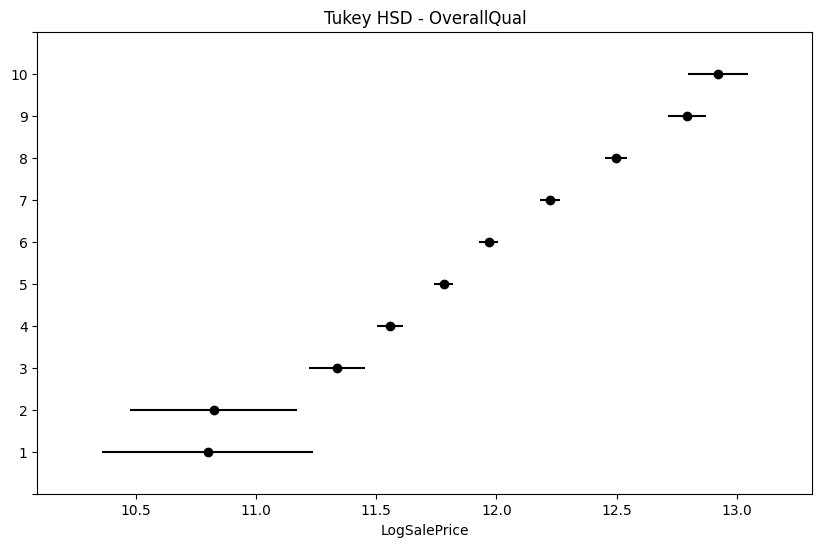


---Tukey HSD pour ExterQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa  -1.4595   0.0 -1.6868 -1.2322   True
    Ex     Gd  -0.4528   0.0 -0.5629 -0.3426   True
    Ex     TA  -0.9261   0.0 -1.0337 -0.8184   True
    Fa     Gd   1.0067   0.0  0.8021  1.2114   True
    Fa     TA   0.5334   0.0  0.3301  0.7368   True
    Gd     TA  -0.4733   0.0 -0.5157 -0.4309   True
---------------------------------------------------


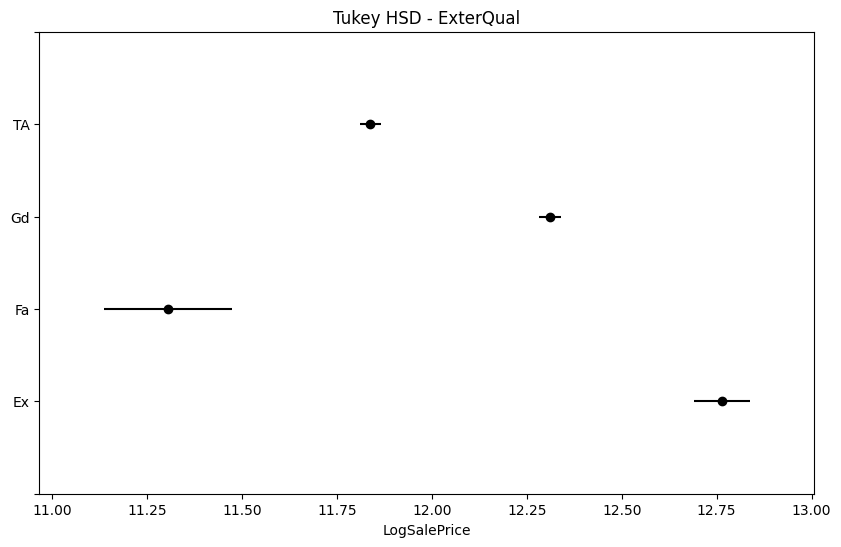


---Tukey HSD pour BsmtQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    Ex     Fa  -1.0228    0.0  -1.178 -0.8676   True
    Ex     Gd  -0.4605    0.0 -0.5409 -0.3801   True
    Ex   None  -1.1107    0.0 -1.2626 -0.9588   True
    Ex     TA  -0.8295    0.0 -0.9096 -0.7495   True
    Fa     Gd   0.5623    0.0  0.4218  0.7028   True
    Fa   None  -0.0879 0.7161 -0.2786  0.1027  False
    Fa     TA   0.1933 0.0016   0.053  0.3336   True
    Gd   None  -0.6502    0.0  -0.787 -0.5134   True
    Gd     TA   -0.369    0.0 -0.4145 -0.3236   True
  None     TA   0.2812    0.0  0.1445  0.4178   True
----------------------------------------------------


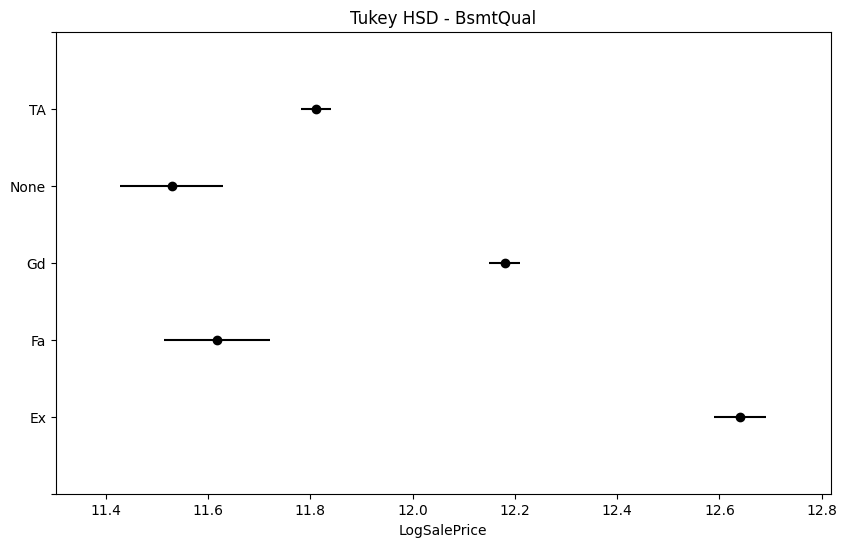


---Tukey HSD pour KitchenQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa   -1.129   0.0 -1.2733 -0.9847   True
    Ex     Gd  -0.4113   0.0  -0.494 -0.3286   True
    Ex     TA   -0.823   0.0 -0.9045 -0.7416   True
    Fa     Gd   0.7178   0.0  0.5914  0.8442   True
    Fa     TA    0.306   0.0  0.1804  0.4316   True
    Gd     TA  -0.4117   0.0 -0.4541 -0.3694   True
---------------------------------------------------


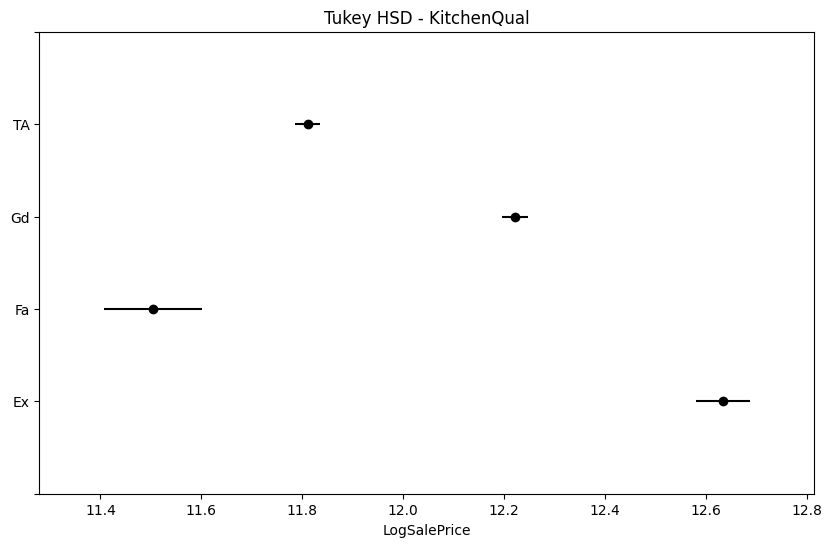


---Tukey HSD pour FireplaceQu---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    Ex     Fa  -0.6615    0.0 -0.9158 -0.4072   True
    Ex     Gd  -0.4135    0.0  -0.613  -0.214   True
    Ex   None  -0.8611    0.0 -1.0579 -0.6643   True
    Ex     Po  -0.9312    0.0 -1.2182 -0.6442   True
    Ex     TA  -0.4836    0.0 -0.6844 -0.2828   True
    Fa     Gd    0.248 0.0006   0.076    0.42   True
    Fa   None  -0.1996 0.0099 -0.3685 -0.0307   True
    Fa     Po  -0.2697 0.0484 -0.5383 -0.0011   True
    Fa     TA   0.1779 0.0406  0.0044  0.3514   True
    Gd   None  -0.4476    0.0 -0.5082 -0.3871   True
    Gd     Po  -0.5177    0.0 -0.7352 -0.3003   True
    Gd     TA  -0.0701 0.0637 -0.1425  0.0022  False
  None     Po  -0.0701 0.9387 -0.2851  0.1449  False
  None     TA   0.3775    0.0  0.3129  0.4421   True
    Po     TA   0.4476    0.0   0.229  0.6662   True
------------

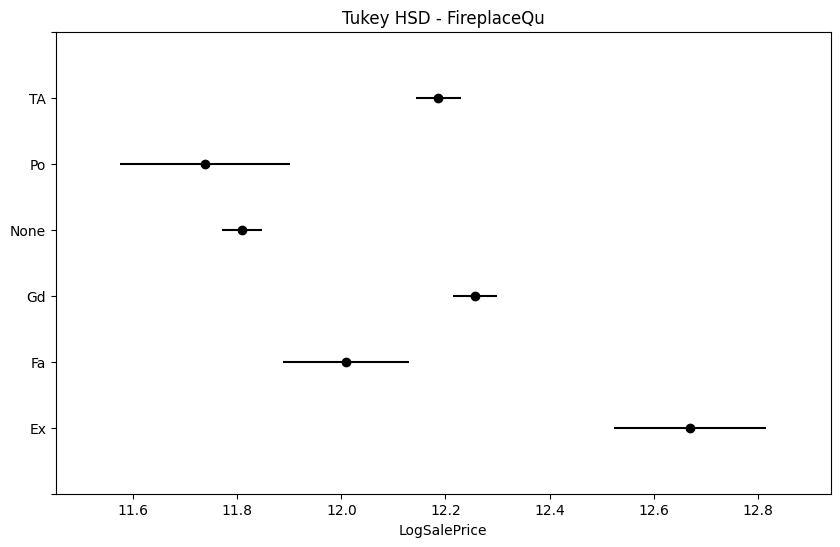


---Tukey HSD pour CentralAir---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     N      Y   0.5692   0.0 0.4914 0.6471   True
-------------------------------------------------


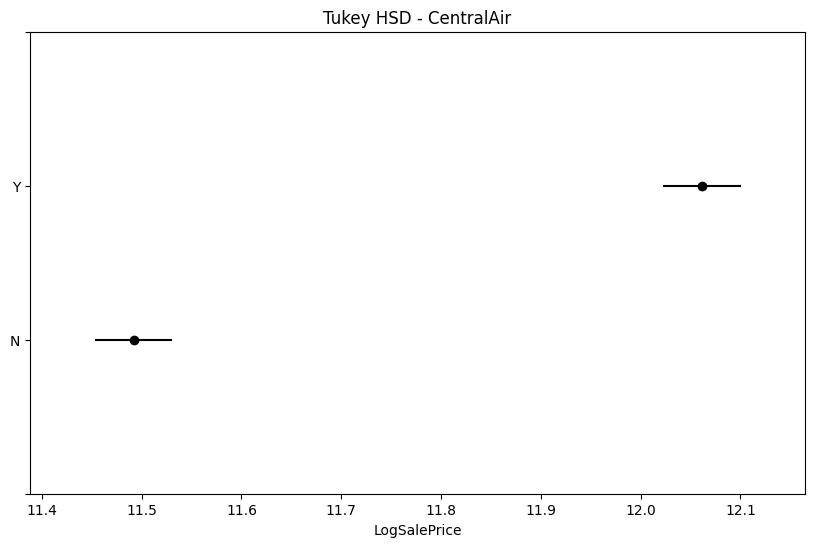


---Tukey HSD pour LotShape---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   IR1    IR2    0.155 0.0611 -0.0048  0.3148  False
   IR1    IR3   0.0419  0.986 -0.2719  0.3558  False
   IR1    Reg  -0.2274    0.0 -0.2825 -0.1723   True
   IR2    IR3   -0.113 0.8357 -0.4595  0.2334  False
   IR2    Reg  -0.3824    0.0 -0.5391 -0.2256   True
   IR3    Reg  -0.2693 0.1188 -0.5816   0.043  False
----------------------------------------------------


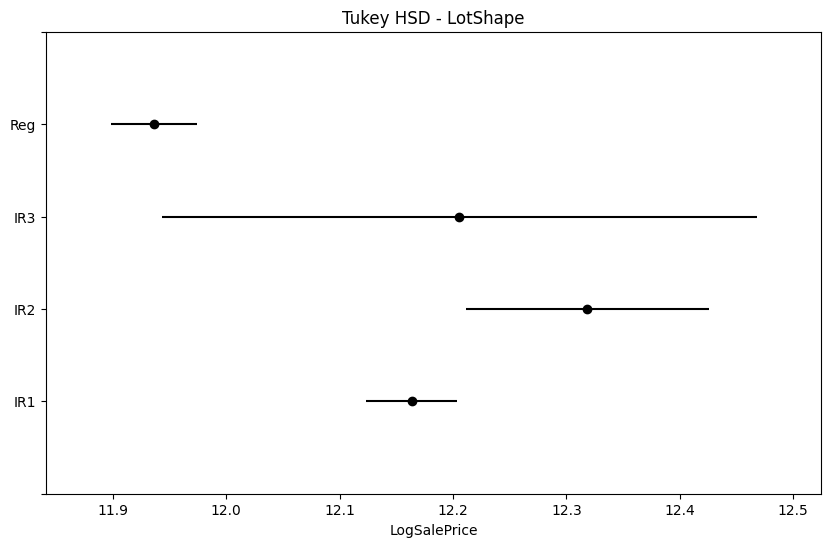


---Tukey HSD pour LandSlope---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Gtl    Mod   0.0563 0.5077 -0.0626 0.1752  False
   Gtl    Sev     0.11 0.5844 -0.1511 0.3711  False
   Mod    Sev   0.0537 0.8977  -0.231 0.3384  False
---------------------------------------------------


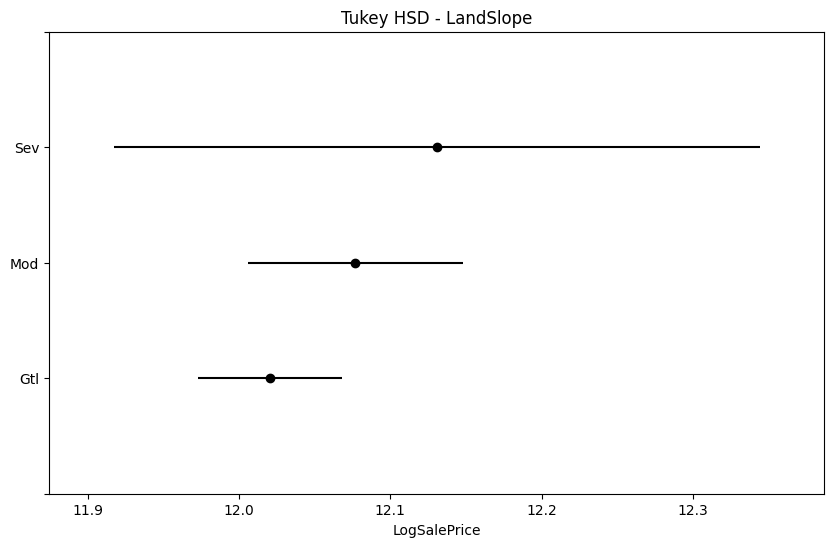


---Tukey HSD pour MoSold---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0838 0.9948  -0.166 0.3335  False
     1      3   0.0668 0.9972 -0.1467 0.2804  False
     1      4   0.0088    1.0 -0.1952 0.2127  False
     1      5   0.0215    1.0  -0.173 0.2161  False
     1      6   0.0566 0.9982 -0.1337  0.247  False
     1      7   0.0795 0.9712 -0.1123 0.2713  False
     1      8   0.0858 0.9728 -0.1228 0.2943  False
     1      9   0.1353 0.7834 -0.1027 0.3732  False
     1     10   0.0568 0.9995 -0.1638 0.2775  False
     1     11   0.1115 0.9038 -0.1146 0.3376  False
     1     12    0.099 0.9738 -0.1428 0.3407  False
     2      3  -0.0169    1.0 -0.2383 0.2045  False
     2      4   -0.075 0.9919 -0.2871 0.1372  False
     2      5  -0.0622 0.9977 -0.2653 0.1409  False
     2      6  -0.0271    1.0 -0.2262  0.172  False
     2      7  -0.0043    1.0 -0.20

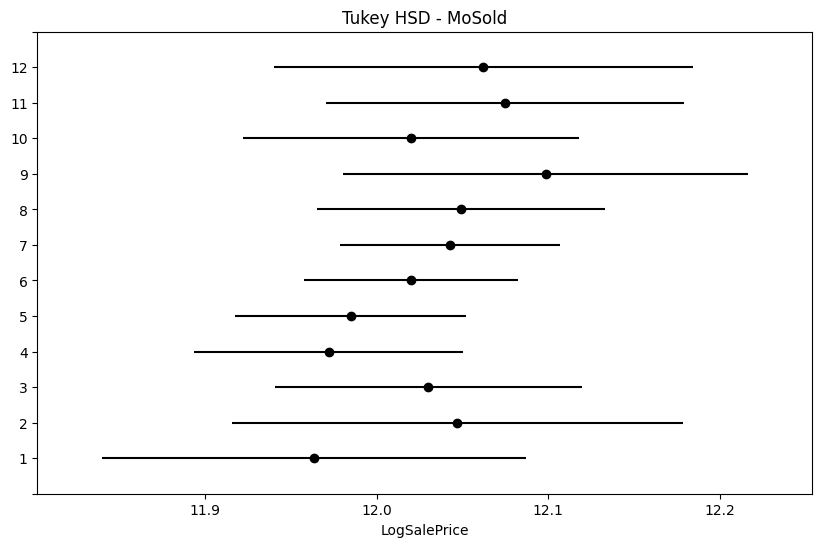


---Tukey HSD pour YrSold---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2006   2007   0.0157 0.9876 -0.0704 0.1018  False
  2006   2008  -0.0208 0.9673 -0.1086  0.067  False
  2006   2009  -0.0262 0.9187 -0.1118 0.0593  False
  2006   2010  -0.0339 0.8971 -0.1369  0.069  False
  2007   2008  -0.0365 0.7814 -0.1233 0.0504  False
  2007   2009  -0.0419 0.6567 -0.1265 0.0426  False
  2007   2010  -0.0496 0.6747 -0.1517 0.0525  False
  2008   2009  -0.0055 0.9998 -0.0917 0.0808  False
  2008   2010  -0.0131 0.9969 -0.1167 0.0904  False
  2009   2010  -0.0077 0.9996 -0.1093  0.094  False
---------------------------------------------------


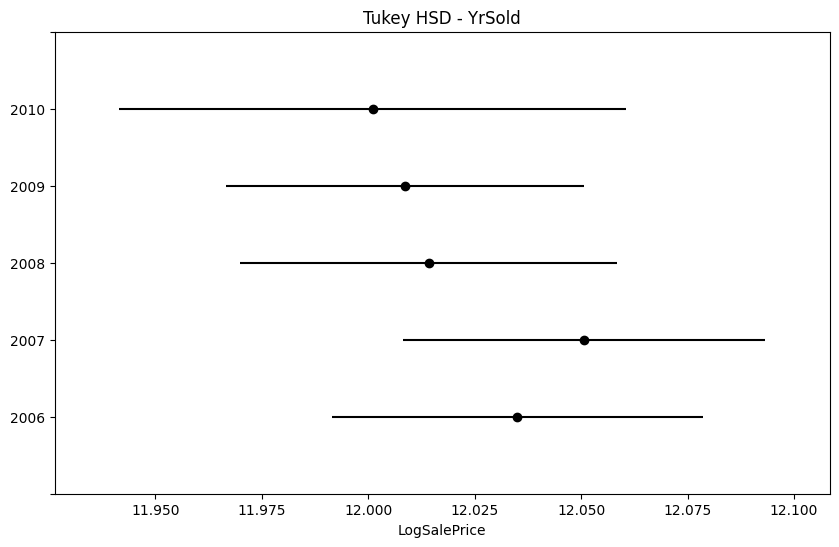

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for col in features:
    tukey = pairwise_tukeyhsd(endog=train_anova['LogSalePrice'], groups=train_anova[col], alpha=0.05)
    print(f"\n---Tukey HSD pour {col}---")
    print(tukey.summary())
    tukey.plot_simultaneous()
    plt.title(f'Tukey HSD - {col}')
    plt.xlabel('LogSalePrice')
    plt.show()

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [ ]:
#Nous allons retenir les 3 features les plus significatives pour la suite de l'analyse
k = 3
# OverallQual, KitchenQual, CentralAir
df_factoriel = train[['LogSalePrice']].copy()
df_factoriel['A'] = (train['OverallQual'] >= 7).astype(int)
df_factoriel['B'] = train['KitchenQual'].isin(['Ex', 'Gd']).astype(int)
df_factoriel['C'] = (train['CentralAir'] == 'Y').astype(int)
means = df_factoriel.groupby(['A', 'B', 'C'])['LogSalePrice'].mean().reset_index()
print("Table des moyennes par combinaison de facteurs:")
print(means)
                     

Table des moyennes par combinaison de facteurs:
   A  B  C  LogSalePrice
0  0  0  0     11.442358
1  0  0  1     11.807476
2  0  1  0     11.835974
3  0  1  1     11.988174
4  1  0  0     11.808353
5  1  0  1     12.133962
6  1  1  0     12.250226
7  1  1  1     12.412245


In [ ]:
print(df_factoriel['B'])

0       1
1       0
2       1
3       1
4       1
       ..
1455    0
1456    0
1457    1
1458    1
1459    0
Name: B, Length: 1460, dtype: int64


---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.